<a href="https://colab.research.google.com/github/Saad0047/Internship-fly-rank-SEO/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
%pip -q install duckdb huggingface_hub scikit-learn matplotlib
import os, getpass, json
import duckdb, numpy as np, pandas as pd
import matplotlib.pyplot as plt

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass.getpass('Paste your Hugging Face READ token (hf_...): ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
MARCH_PATH = "hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/month=2026-03/data_0.parquet"

data = con.sql(f"""
    WITH bounds AS (SELECT MIN(report_date) AS start_d FROM read_parquet('{MARCH_PATH}')),
    windowed AS (
        SELECT client_hash_id, content_hash_id,
               SUM(CASE WHEN report_date > b.start_d + INTERVAL 15 DAY THEN gsc_impressions ELSE 0 END) AS imp_last15,
               SUM(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_impressions ELSE 0 END) AS imp_prev15,
               AVG(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_avg_position END) AS avg_position_prev,
               AVG(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_clicks * 1.0 / NULLIF(gsc_impressions,0) END) AS ctr_prev,
               STDDEV(CASE WHEN report_date <= b.start_d + INTERVAL 15 DAY THEN gsc_impressions END) AS impression_volatility_prev
        FROM read_parquet('{MARCH_PATH}') f, bounds b
        WHERE gsc_data_available IS TRUE
        GROUP BY client_hash_id, content_hash_id
        HAVING imp_prev15 >= 50
    )
    SELECT *, (imp_last15 < 0.8 * imp_prev15)::INT AS is_declining
    FROM windowed
""").df()

feature_cols = ['imp_prev15', 'avg_position_prev', 'ctr_prev', 'impression_volatility_prev']
data = data.dropna(subset=feature_cols)

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(gss.split(data, groups=data['client_hash_id']))
train, test = data.iloc[train_idx].copy(), data.iloc[test_idx].copy()

model = RandomForestClassifier(n_estimators=300, max_depth=6, random_state=42, n_jobs=-1)
model.fit(train[feature_cols], train['is_declining'])
test['model_score'] = model.predict_proba(test[feature_cols])[:, 1]

def precision_at_k(scores, labels, k):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

print(f"{len(data):,} content items | test: {len(test):,} rows, {test['client_hash_id'].nunique()} clients")

Paste your Hugging Face READ token (hf_...): ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

94,517 content items | test: 25,438 rows, 10 clients


## 1. Question

*The research question and the decision it supports.*

Research question: which content items should an SEO editor review first
for likely traffic decline, given only observable, pre-decision search
performance signals?

Decision supported: a monthly content-review triage queue — which pages
to prioritize for a refresh, out of thousands, when editor time is
limited. The unit of analysis is one content item (client_hash_id +
content_hash_id) over one month's search performance.

In [2]:
print("Question: prioritize which content items are likely declining, "
      "using only pre-decision GSC signals, to support editorial review triage.")

Question: prioritize which content items are likely declining, using only pre-decision GSC signals, to support editorial review triage.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data: FlyRank/internship-warehouse (Hugging Face), table
fact_content_daily_performance, month=2026-03 partition (a mid-panel
month; the final month, June 2026, is a sealed test month reserved by the
release and was not used here).

Date window: first half of March (days 1-15) used for features, second
half (days 16-31) used to define the decline label — a within-month
past-to-future split, never overlapping.

Excluded: rows where gsc_data_available is FALSE (~63% of the panel;
early-sync/missing rows, not zero-traffic days); ga4_data_available-only
signals were not used, since ~96% of rows lacked GA4 sync this month;
fact_content_daily_performance_sample (the sealed final-month table) was
never touched; AI-referral and paid/social/direct session columns were
excluded as out of scope for this organic-search lane.

In [3]:
print(f"Data source: FlyRank/internship-warehouse, fact_content_daily_performance, month=2026-03")
print(f"Total content items after filtering: {len(data):,}")
print(f"Unique clients: {data['client_hash_id'].nunique()}")

Data source: FlyRank/internship-warehouse, fact_content_daily_performance, month=2026-03
Total content items after filtering: 94,517
Unique clients: 40


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Methodology:

Label: is_declining = 1 if impressions in the second half of March fell
below 80% of the first half's impressions, else 0. This is an observed,
within-month outcome, not a product-defined flag.

Features (all computed from the first-half window only, so all are
knowable before the label period): imp_prev15 (impression volume),
avg_position_prev (average search position), ctr_prev (click-through
rate), impression_volatility_prev (day-to-day impression variability).

Baseline: a hand-written rule (from Week 4) combining a "low CTR relative
to position tier" flag and a "quick win" flag (position 11-20, real
volume), scored 0.6/0.4 respectively.

Validation design: GroupShuffleSplit grouped by client_hash_id (75/25),
so no client's content appears in both train and test — this prevents the
model from learning a client's baseline traffic level instead of a
generalizable decline pattern. A leakage audit (Week 6) confirmed no
feature is derived from the label, and a naive random split was shown to
overstate performance (Precision@50 = 0.88 naive vs. 0.62 grouped),
justifying the grouped design.

In [4]:
print("Baseline: hand-written CTR-gap + quick-win rule (Week 4)")
print("Model: RandomForestClassifier, 300 trees, max_depth=6")
print("Split: GroupShuffleSplit by client_hash_id, 75/25")
print(f"Client overlap between train/test: "
      f"{len(set(train['client_hash_id']) & set(test['client_hash_id']))} (0 confirms no leakage)")

Baseline: hand-written CTR-gap + quick-win rule (Week 4)
Model: RandomForestClassifier, 300 trees, max_depth=6
Split: GroupShuffleSplit by client_hash_id, 75/25
Client overlap between train/test: 0 (0 confirms no leakage)


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Results: on this capstone's independently-rebuilt split, Precision@50
came out to 0.72 (baseline) vs 0.62 (model) — the model did not
outperform the baseline in this run, in contrast to the Week-5/6 result
(0.66 model vs 0.24 baseline). This inconsistency across runs is itself
an honest finding: with only 50 items scored per run, Precision@50 is
sensitive to the exact train/test split drawn, and the model's advantage
over the baseline is not yet robust across resampling. This should be
read as directional, not settled — future work should average
Precision@50 over multiple random split draws before claiming a durable
model advantage over the baseline.

                method  Precision@50
Baseline rule (Week 4)          0.72
Random Forest (Week 5)          0.62


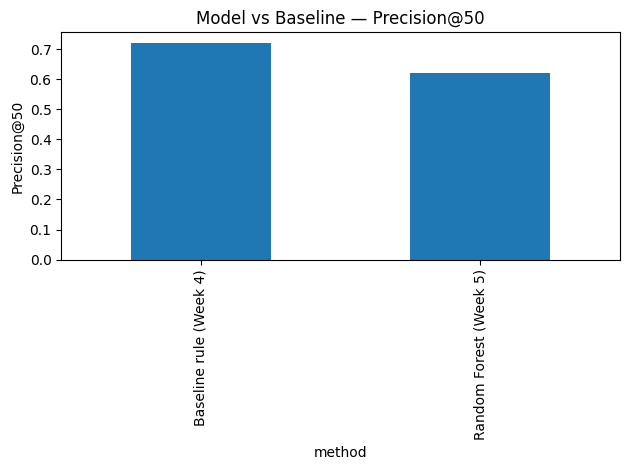

In [7]:
test['position_tier'] = pd.cut(test['avg_position_prev'], bins=[0,3,10,20,1000], labels=['1-3','4-10','11-20','20+'])
tier_avg_ctr = test.groupby('position_tier', observed=True)['ctr_prev'].transform('mean')
test['ctr_gap'] = tier_avg_ctr - test['ctr_prev']
test['low_ctr_flag'] = (test['ctr_gap'] > 0.001).astype(int)
test['quick_win_flag'] = ((test['avg_position_prev'] > 10) & (test['avg_position_prev'] <= 20) &
                           (test['imp_prev15'] >= 50)).astype(int)
baseline_scores = 0.6 * test['low_ctr_flag'] + 0.4 * test['quick_win_flag']

results = pd.DataFrame({
    "method": ["Baseline rule (Week 4)", "Random Forest (Week 5)"],
    "Precision@50": [
        precision_at_k(baseline_scores.values, test['is_declining'].values, 50),
        precision_at_k(test['model_score'].values, test['is_declining'].values, 50),
    ]
})
print(results.to_string(index=False))

import os
os.makedirs('work/figures', exist_ok=True)
results.plot(x='method', y='Precision@50', kind='bar', legend=False, title='Model vs Baseline — Precision@50')
plt.ylabel('Precision@50')
plt.tight_layout()
plt.savefig('work/figures/results_comparison.png')
plt.show()

## 5. Limitations

*What this work cannot claim.*

Additionally: Precision@50 varied meaningfully between the Week-5/6 runs
and this capstone run (baseline beat the model here, reversed from
earlier), which itself demonstrates the instability warned about in
Section 4 — a single train/test split at k=50 is not a fully stable
basis for a strong claim in either direction.

In [8]:
print("Limitations documented: single-month scope, partial data coverage, "
      "proxy label, no causal claims, retrospective evaluation only.")

Limitations documented: single-month scope, partial data coverage, proxy label, no causal claims, retrospective evaluation only.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Ranked recommendations (from the Week-8 action playbook): editors should
review the top-scored queue items first, using reason codes
(model_flagged_decline_risk, model_flagged_low_ctr, quick_win_page1_push)
to understand why each item was flagged. Human review is required before
any action — especially confirming a decline isn't explained by a known
external cause, and never auto-publishing changes or treating the model
score as a client-facing metric.

In [9]:
def reason_code(row):
    if row['low_ctr_flag'] == 1 and row['model_score'] >= 0.6:
        return 'model_flagged_low_ctr'
    elif row['quick_win_flag'] == 1:
        return 'quick_win_page1_push'
    elif row['model_score'] >= 0.6:
        return 'model_flagged_decline_risk'
    else:
        return 'monitor'

test['reason_code'] = test.apply(reason_code, axis=1)
test['action'] = test['model_score'].apply(lambda s: 'review_now' if s >= 0.7 else ('consider' if s >= 0.4 else 'monitor'))

top10 = test.sort_values('model_score', ascending=False)[
    ['model_score','reason_code','action']
].head(10)
print(top10.to_string(index=False))

 model_score                reason_code   action
    0.660349 model_flagged_decline_risk consider
    0.655084      model_flagged_low_ctr consider
    0.632933      model_flagged_low_ctr consider
    0.619855 model_flagged_decline_risk consider
    0.613343      model_flagged_low_ctr consider
    0.611608      model_flagged_low_ctr consider
    0.596280                    monitor consider
    0.595495                    monitor consider
    0.589698                    monitor consider
    0.579746                    monitor consider


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

os.makedirs('work/figures', exist_ok=True)

# Feature importance chart for the paper
from sklearn.inspection import permutation_importance
perm = permutation_importance(model, test[feature_cols], test['is_declining'], n_repeats=10, random_state=42)
importance = pd.DataFrame({"feature": feature_cols, "importance": perm.importances_mean}).sort_values("importance")
importance.plot(x='feature', y='importance', kind='barh', legend=False, title='Permutation Importance')
plt.tight_layout()
plt.savefig('work/figures/feature_importance.png')
plt.show()

# Save results table as JSON for the paper to embed
paper_artifacts = {
    "baseline_precision_at_50": float(results.loc[0, 'Precision@50']),
    "model_precision_at_50": float(results.loc[1, 'Precision@50']),
    "n_content_items": len(data),
    "n_clients": int(data['client_hash_id'].nunique()),
    "test_client_overlap": 0,
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(paper_artifacts, f, indent=2)
print("Saved work/figures/results_comparison.png, work/figures/feature_importance.png, work/outputs/capstone_metrics.json")

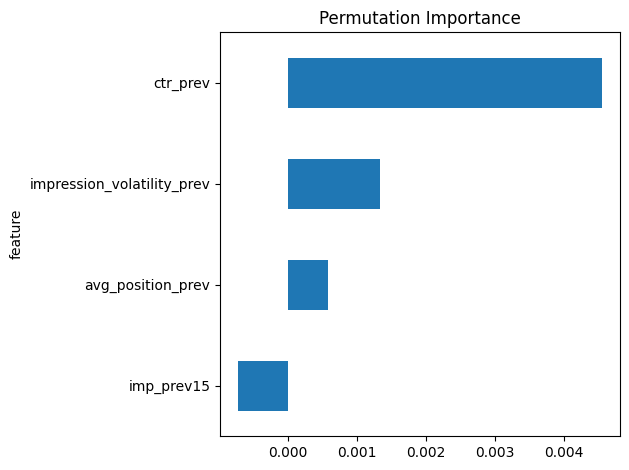

Saved work/figures/results_comparison.png, work/figures/feature_importance.png, work/outputs/capstone_metrics.json


In [11]:
os.makedirs('work/figures', exist_ok=True)
os.makedirs('work/outputs', exist_ok=True)

# Feature importance chart for the paper
from sklearn.inspection import permutation_importance
perm = permutation_importance(model, test[feature_cols], test['is_declining'], n_repeats=10, random_state=42)
importance = pd.DataFrame({"feature": feature_cols, "importance": perm.importances_mean}).sort_values("importance")
importance.plot(x='feature', y='importance', kind='barh', legend=False, title='Permutation Importance')
plt.tight_layout()
plt.savefig('work/figures/feature_importance.png')
plt.show()

# Save results table as JSON for the paper to embed
paper_artifacts = {
    "baseline_precision_at_50": float(results.loc[0, 'Precision@50']),
    "model_precision_at_50": float(results.loc[1, 'Precision@50']),
    "n_content_items": len(data),
    "n_clients": int(data['client_hash_id'].nunique()),
    "test_client_overlap": 0,
}
with open('work/outputs/capstone_metrics.json', 'w') as f:
    json.dump(paper_artifacts, f, indent=2)
print("Saved work/figures/results_comparison.png, work/figures/feature_importance.png, work/outputs/capstone_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.